Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter

 Loading dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_cuaca = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM ML/Praktikum10/Data/weather_classification_data.csv')


Menampilkan data awal  

In [ ]:
df_cuaca.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy



Mengecek Struktur Dataset

In [ ]:
print("Informasi Dataset:")
df_cuaca.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
df_cuaca.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


 Data Cleaning

In [ ]:
print(df_cuaca['Cloud Cover'].unique())
print(df_cuaca['Season'].unique())
print(df_cuaca['Location'].unique())
print(df_cuaca['Weather Type'].unique())

['partly cloudy' 'clear' 'overcast' 'cloudy']
['Winter' 'Spring' 'Summer' 'Autumn']
['inland' 'mountain' 'coastal']
['Rainy' 'Cloudy' 'Sunny' 'Snowy']


Menghapus Kolom yang Tidak Digunakan

In [ ]:
df_cuaca.drop(columns=['Cloud Cover'],inplace=True)

Mengubah Nilai Kategorikal menjadi Numerik

In [ ]:
replacement = {
    'Season': {
        'Winter': 0,
        'Spring': 1,
        'Summer': 2,
        'Autumn': 3
    },
    'Location': {
        'coastal': 0,
        'inland': 1,
        'mountain': 2
    },
    'Weather Type': {
        'Sunny': 0,
        'Cloudy': 1,
        'Rainy': 2,
        'Snowy': 3
    }
}

df_cuaca = df_cuaca.replace(replacement, inplace=False)
df_cuaca.head()

/tmp/ipython-input-2843386111.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cuaca = df_cuaca.replace(replacement, inplace=False)


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,1010.82,2,0,3.5,1,2
1,39.0,96,8.5,71.0,1011.43,7,1,10.0,1,1
2,30.0,64,7.0,16.0,1018.72,5,1,5.5,2,0
3,38.0,83,1.5,82.0,1026.25,7,1,1.0,0,0
4,27.0,74,17.0,66.0,990.67,1,0,2.5,2,2


Melakukan Encoding pada Dataset Uji

In [ ]:
df_cuaca = df_cuaca.replace(replacement, inplace=False)
df_cuaca.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,1010.82,2,0,3.5,1,2
1,39.0,96,8.5,71.0,1011.43,7,1,10.0,1,1
2,30.0,64,7.0,16.0,1018.72,5,1,5.5,2,0
3,38.0,83,1.5,82.0,1026.25,7,1,1.0,0,0
4,27.0,74,17.0,66.0,990.67,1,0,2.5,2,2


Cek missing value


In [ ]:
df_cuaca.isnull().sum()


,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0
Weather Type,0


Analisis Korelasi Fitur

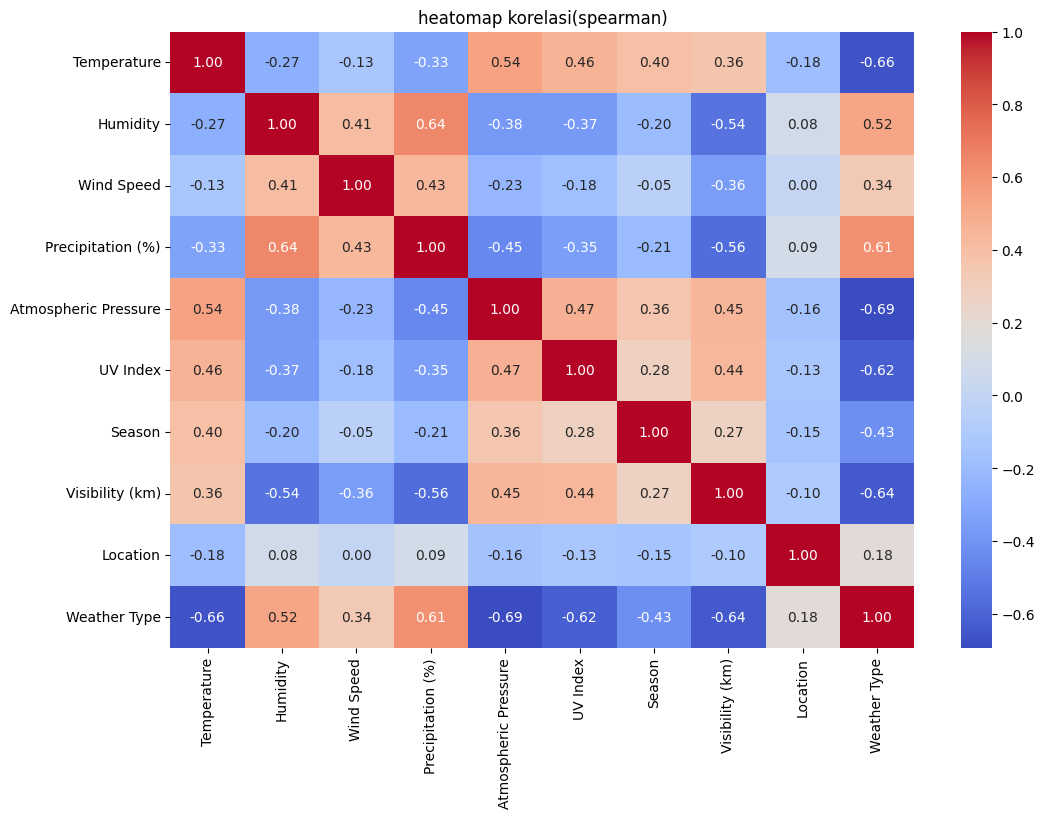

In [ ]:
correlation_matrix = df_cuaca.corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",cbar=True)
plt.title("heatomap korelasi(spearman)")
plt.show()

Visualisasi Distribusi

/tmp/ipython-input-697974990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season', data=df_cuaca,palette='Set2')


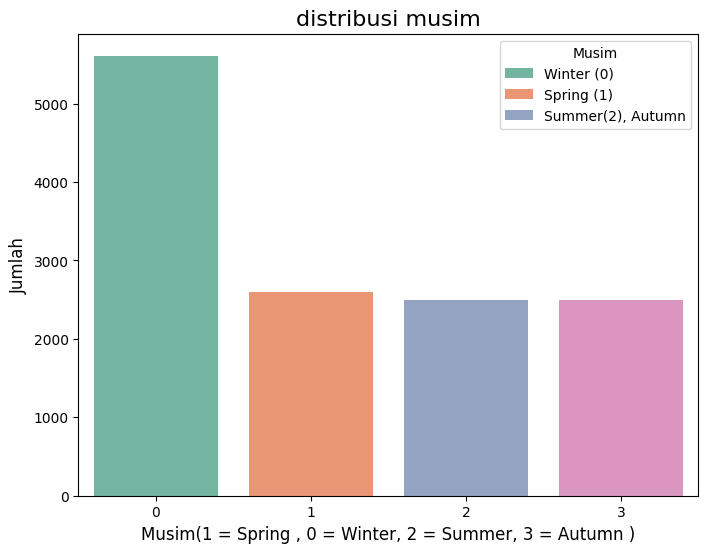

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Season', data=df_cuaca,palette='Set2')

plt.title('distribusi musim', fontsize=16)
plt.xlabel('Musim(1 = Spring , 0 = Winter, 2 = Summer, 3 = Autumn )', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.legend(title='Musim', labels=['Winter (0)', 'Spring (1)','Summer(2), Autumn'], loc='upper right')
plt.show()

Pemisahan Data dan Normalisasi

In [ ]:
X_cuaca = df_cuaca.drop(columns=['Season'])
y_cuaca = df_cuaca['Season']
scaler = StandardScaler()
X_cuaca_scaled = scaler.fit_transform(X_cuaca)

 Menangani Ketidakseimbangan dengan SMOTE

In [ ]:
print("BEFORE SMOTE")
print(y_cuaca.value_counts())

sm = SMOTE(random_state=42,k_neighbors=1)
X_train_smote, y_train_smote = sm.fit_resample(X_cuaca_scaled, y_cuaca)
print("AFTER SMOTE")
print(y_train_smote.value_counts())

BEFORE SMOTE
Season
0    5610
1    2598
3    2500
2    2492
Name: count, dtype: int64
AFTER SMOTE
Season
0    5610
1    5610
2    5610
3    5610
Name: count, dtype: int64


Menentukan Parameter Terbaik

In [ ]:
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Best Score: 0.8354723707664885


 Melatih Model KNN Terbaik dan Melakukan Prediks

In [ ]:
best_knn = grid.best_estimator_
best_knn.fit(X_cuaca_scaled, y_cuaca)

y_pred = best_knn.predict(X_cuaca_scaled)

Evaluasi Model dengan Classification Report

In [ ]:
print("\nClassification Reports:")
print(classification_report(y_cuaca, y_pred))


Classification Reports:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5610
           1       1.00      1.00      1.00      2598
           2       1.00      1.00      1.00      2492
           3       1.00      1.00      1.00      2500

    accuracy                           1.00     13200
   macro avg       1.00      1.00      1.00     13200
weighted avg       1.00      1.00      1.00     13200



 Evaluasi dengan Confusion Matrix

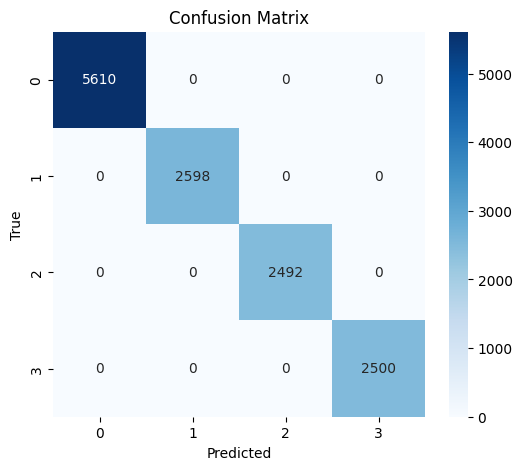

In [ ]:
cm = confusion_matrix(y_cuaca, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Validasi Model dengan Cross Validation

In [ ]:
cv_scores = cross_val_score(best_knn, X_train_smote, y_train_smote, cv=5)
print("Cross-Validation Scores:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-Validation Scores: 0.8354723707664885
Std Dev: 0.06217218004434773


Menentukan Nilai K Optimal dengan Elbow Method

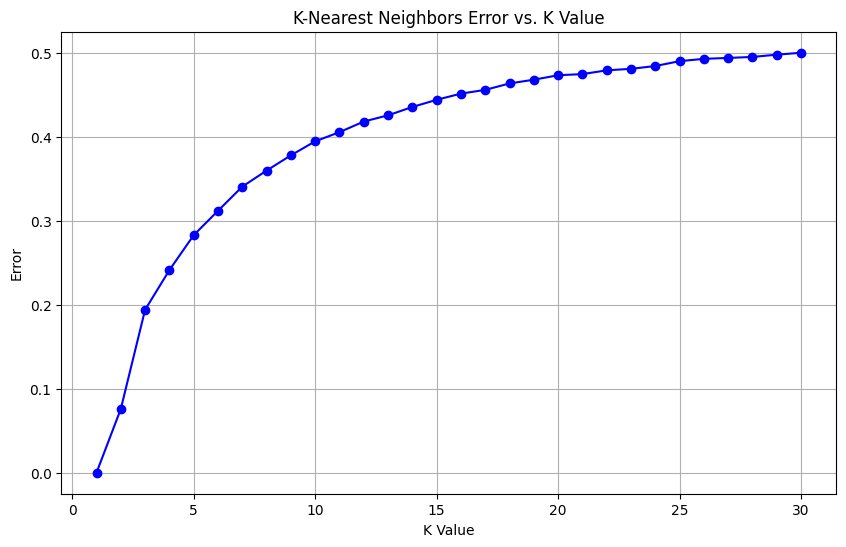

In [ ]:
errors = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)
    pred = knn.predict(X_cuaca_scaled)
    errors.append(np.mean(pred != y_cuaca))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), errors, marker='o', linestyle='-', color='b')
plt.title('K-Nearest Neighbors Error vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.grid(True)
plt.show()